# CS 6220: Homework 2 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Global plot styling and random seed
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
SEED = 42
np.random.seed(SEED)

# Global true functions and feature transformations
linear_func = lambda x: 2 * x + 1
cubic_func = lambda x: 0.5 * x**3 - x**2 + x
square_func = lambda x: x**2
cube_func = lambda x: x**3


---
## Part 1: Synthetic Data Generator
Generates tabular data with columns `[x, f_1(x), ..., f_d(x)]` and target `y = f(x) + noise`, where noise is drawn uniformly from `[-epsilon, epsilon]`.


In [2]:
def generate_noisy_dataset(
    func_list,
    true_func,
    x_range,
    n_samples,
    noise_level,
    random_state=None
):
    #Generates synthetic tabular dataset with specified feature transformations and uniform noise.

   
    if random_state is not None:
        np.random.seed(random_state)

    x_min, x_max = x_range
    x_raw = np.random.uniform(x_min, x_max, size=n_samples)

    cols = [x_raw] + [f(x_raw) for f in func_list]
    X = np.column_stack(cols)

    noise = np.random.uniform(-noise_level, noise_level, size=n_samples)
    y = true_func(x_raw) + noise

    return X, y, x_raw


def split_dataset(
    X,
    y,
    x_raw=None,
    train_ratio=0.8,
    random_state=42
):
    #Splits dataset into fixed independent training and testing sets.

    if random_state is not None:
        np.random.seed(random_state)

    n_samples = len(y)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    n_train = int(train_ratio * n_samples)
    train_idx = indices[:n_train]
    test_idx = indices[n_train:]

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    if x_raw is not None:
        x_train = x_raw[train_idx]
        x_test = x_raw[test_idx]
        return X_train, y_train, X_test, y_test, x_train, x_test

    return X_train, y_train, X_test, y_test


---
## Part 2: Linear Regression Implementation
Solves weight vector $\boldsymbol{\beta} = (X^T X)^{-1} X^T Y$ using matrix operations, with an intercept column of 1s prepended to $X$.


In [3]:
def fit(X, y):
    #Fits linear regression model weights beta using matrix Normal Equations: beta = (X_aug^T X_aug)^(-1) X_aug^T y.

    ones = np.ones((X.shape[0], 1))
    X_aug = np.hstack([ones, X])
    # Note: np.linalg.solve(X^T X, X^T Y) solves (X^T X) beta = X^T Y.
    # It is mathematically equivalent to beta = (X^T X)^(-1) X^T Y, but more numerically stable than direct matrix inversion.
    beta = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    return beta


def predict(beta, X):
    #Generates predictions y_pred = X_aug * beta for input test feature matrix X.

    ones = np.ones((X.shape[0], 1))
    X_aug = np.hstack([ones, X])
    return X_aug @ beta


def evaluate_model(predictions, true_outputs):
    #Calculates Root Mean Squared Error (RMSE) between predictions and ground truth y.

    return np.sqrt(np.mean((predictions - true_outputs) ** 2))


---
## Part 3: Regression Decision Tree Implementation
Recursively partitions feature space to minimize Sum of Squared Errors (SSE). Split stopping is controlled by `min_records`.


In [4]:
class TreeNode:
    #Represents a node in the Regression Decision Tree.

    def __init__(
        self,
        feature_idx=None,
        threshold=None,
        left=None,
        right=None,
        value=None,
        n_samples=0
    ):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.n_samples = n_samples

    @property
    def is_leaf(self):
        """Returns True if the node is a leaf node."""
        return self.value is not None


class RegressionTree:
    #Regression Decision Tree built from scratch using recursive binary splits minimizing SSE.

    def __init__(self, min_records=1):
        self.min_records = min_records
        self.root = None

    def fit(self, X, y, min_records=None):
        #Fits the regression tree on training dataset (X, y).

        if min_records is not None:
            self.min_records = min_records

        X = np.asarray(X)
        y = np.asarray(y)

        self.root = self._build_tree(X, y)
        return self

    def _build_tree(self, X, y):
        #Recursively builds tree nodes by finding optimal feature threshold split minimizing SSE.
        n_samples, n_features = X.shape
        node_value = np.mean(y)

        if (
            n_samples < self.min_records
            or n_samples <= 1
            or np.var(y) == 0
        ):
            return TreeNode(value=node_value, n_samples=n_samples)

        best_sse = float("inf")
        best_feature = None
        best_threshold = None
        best_left_idx = None
        best_right_idx = None

        for feature_idx in range(n_features):
            X_col = X[:, feature_idx]
            unique_values = np.unique(X_col)

            if len(unique_values) <= 1:
                continue

            thresholds = (unique_values[:-1] + unique_values[1:]) / 2.0

            for threshold in thresholds:
                left_idx = X_col <= threshold
                right_idx = X_col > threshold

                if not np.any(left_idx) or not np.any(right_idx):
                    continue

                y_left = y[left_idx]
                y_right = y[right_idx]

                left_sse = np.sum((y_left - np.mean(y_left)) ** 2)
                right_sse = np.sum((y_right - np.mean(y_right)) ** 2)
                total_sse = left_sse + right_sse

                if total_sse < best_sse:
                    best_sse = total_sse
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_left_idx = left_idx
                    best_right_idx = right_idx

        if best_feature is None:
            return TreeNode(value=node_value, n_samples=n_samples)

        left_child = self._build_tree(X[best_left_idx], y[best_left_idx])
        right_child = self._build_tree(X[best_right_idx], y[best_right_idx])

        return TreeNode(
            feature_idx=best_feature,
            threshold=best_threshold,
            left=left_child,
            right=right_child,
            n_samples=n_samples
        )

    def _predict_sample(self, x, node):
        #Traverses the tree to predict target value for a single sample x.
        if node.is_leaf:
            return node.value

        if x[node.feature_idx] <= node.threshold:
            return self._predict_sample(x, node.left)

        return self._predict_sample(x, node.right)

    def predict(self, X):
        #Predicts regression target for feature matrix X.

        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        return np.array([self._predict_sample(x, self.root) for x in X])

    def get_splits(self, node=None, feature_idx=0):
        #Recursively extracts split thresholds for a given feature index.
        if node is None:
            node = self.root

        if node is None or node.is_leaf:
            return []

        splits = []
        if node.feature_idx == feature_idx:
            splits.append(node.threshold)

        splits.extend(self.get_splits(node.left, feature_idx))
        splits.extend(self.get_splits(node.right, feature_idx))

        return splits

    def count_nodes_and_leaves(self, node=None):
        #Counts total nodes, total leaf nodes, and leaf sample counts.

        if node is None:
            node = self.root

        if node is None:
            return 0, 0, []

        if node.is_leaf:
            return 1, 1, [node.n_samples]

        left_nodes, left_leaves, left_counts = self.count_nodes_and_leaves(node.left)
        right_nodes, right_leaves, right_counts = self.count_nodes_and_leaves(node.right)

        total_nodes = 1 + left_nodes + right_nodes
        total_leaves = left_leaves + right_leaves
        leaf_counts = left_counts + right_counts

        return total_nodes, total_leaves, leaf_counts

    def visualize(
        self,
        x_range=(0.0, 1.0),
        true_func=None,
        X_train=None,
        y_train=None,
        func_list=None,
        title=None,
        ax=None
    ):
        #Plots training scatterplot, true function, tree prediction line, and feature split boundaries.
        if func_list is None:
            func_list = []

        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 4))

        x_grid = np.linspace(x_range[0], x_range[1], 500)
        grid_cols = [x_grid] + [f(x_grid) for f in func_list]
        X_grid = np.column_stack(grid_cols)

        if X_train is not None and y_train is not None:
            ax.scatter(X_train[:, 0], y_train, alpha=0.3, label="Train Data", s=12)

        if true_func is not None:
            ax.plot(x_grid, true_func(x_grid), "k--", linewidth=2, label="True f(x)")

        predictions = self.predict(X_grid)
        ax.plot(x_grid, predictions, "r-", linewidth=2, label="Tree Prediction")

        splits = self.get_splits(feature_idx=0)
        many = len(splits) > 60
        first = True
        for split in splits:
            if x_range[0] <= split <= x_range[1]:
                ax.axvline(
                    x=split,
                    linestyle=":",
                    alpha=0.15 if many else 0.3,
                    linewidth=0.4 if many else 1.0,
                    label="Splits" if first else None
                )
                first = False

        ax.set_xlabel("x")
        ax.set_ylabel("y")

        if title is not None:
            ax.set_title(title, fontsize=9, fontweight="bold")

        ax.legend(loc="best", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.4)


---
## Part 4: Linear Regression Experiments (Q3 & Q4)
Evaluates Linear Regression across 8 setup combinations (Linear vs. Cubic true functions, noise levels 0.01 vs. 0.1, raw vs. polynomial feature schemas).


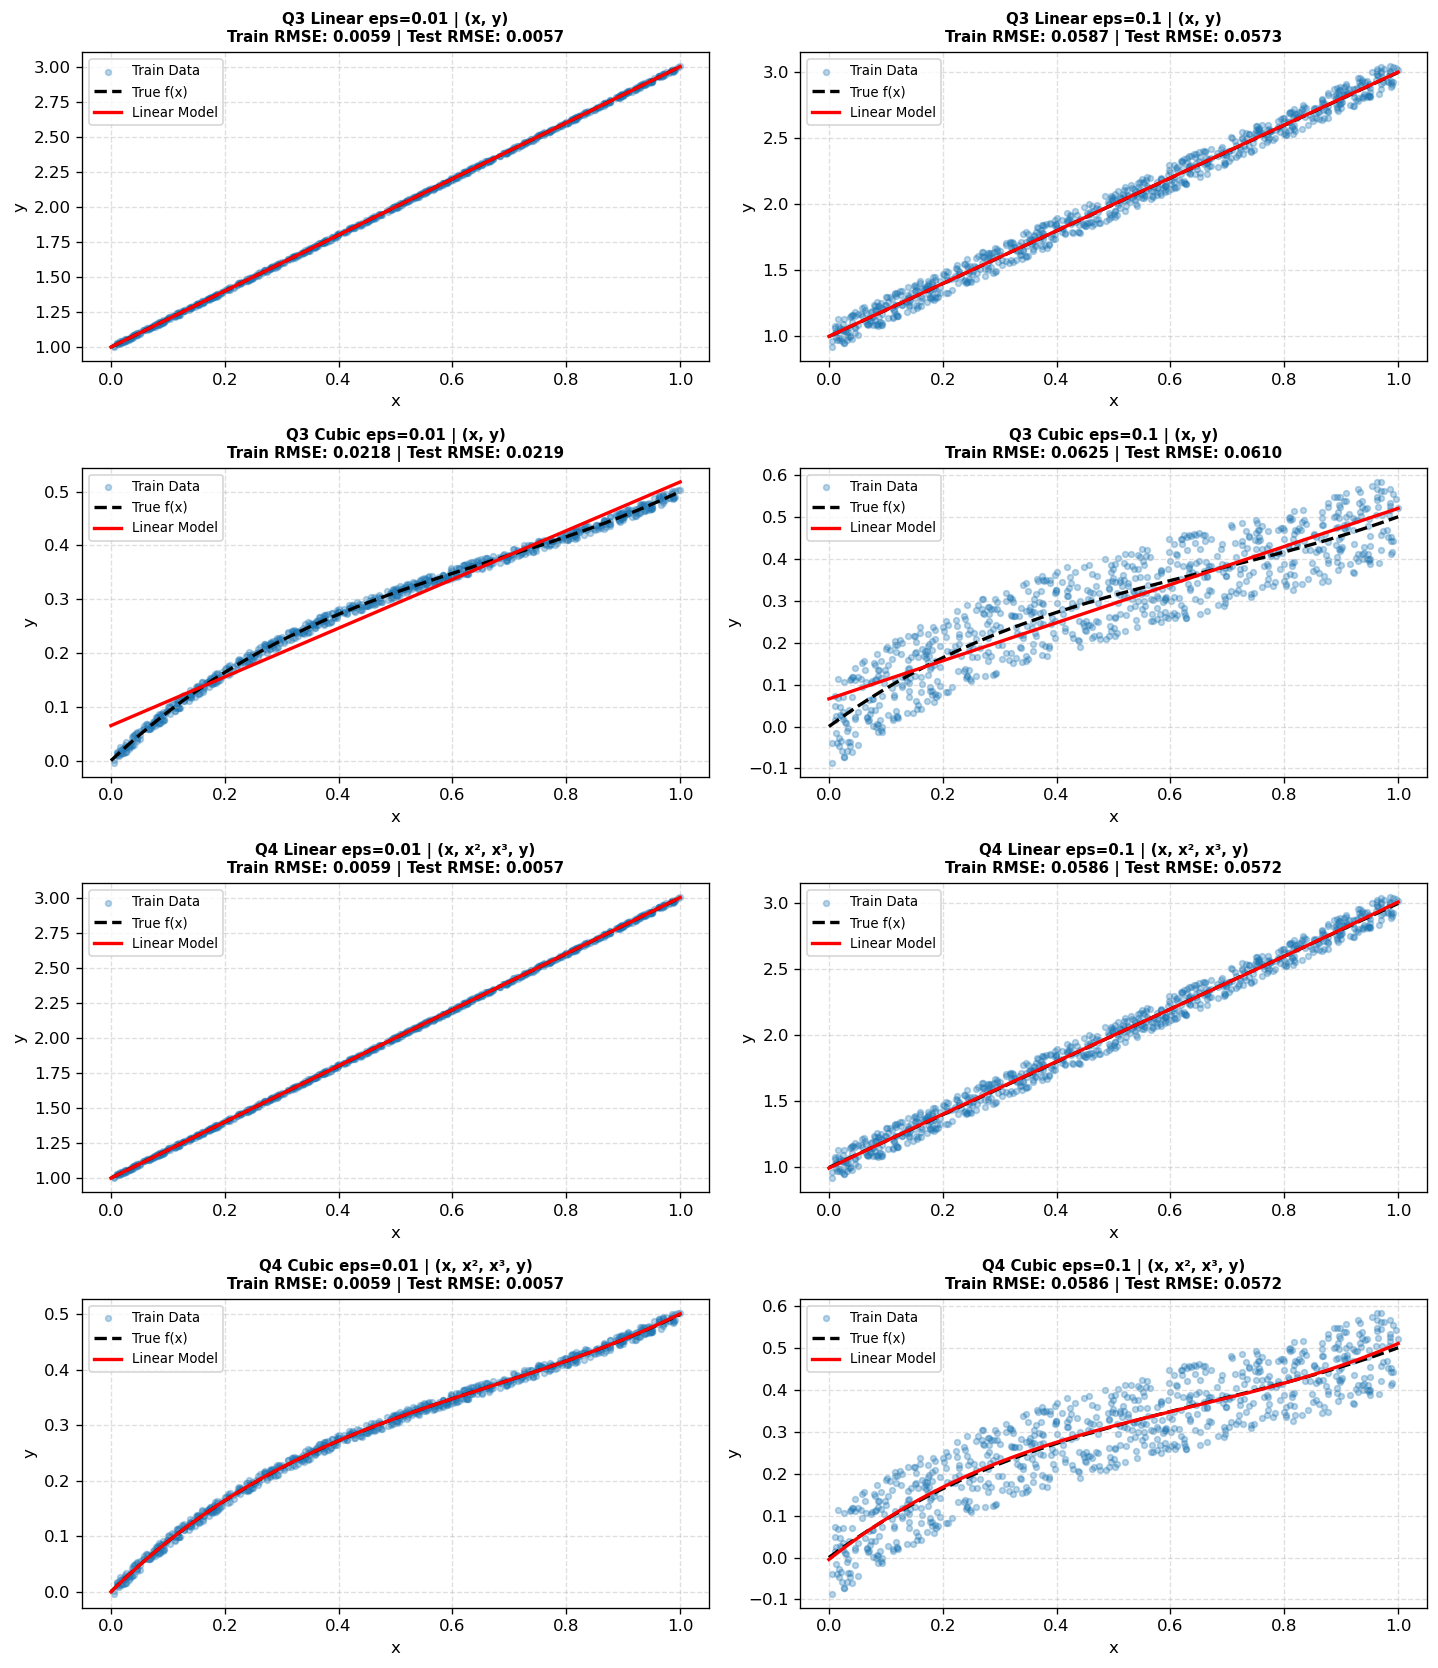

,Setup,True fn,Noise,Schema,Train RMSE,Test RMSE,Irreducible RMSE,Beta,y_true(10),y_pred(10),Extrap Error
0,Q3 Linear eps=0.01,Linear,0.01,"(x, y)",0.00587,0.00573,0.00577,"[1.0001, 2.0001]",21.0,21.00,0.00
1,Q3 Linear eps=0.1,Linear,0.10,"(x, y)",0.05867,0.05731,0.05774,"[1.0008, 2.0015]",21.0,21.02,0.02
2,Q3 Cubic eps=0.01,Cubic,0.01,"(x, y)",0.02180,0.02195,0.00577,"[0.0651, 0.4527]",410.0,4.59,405.41
3,Q3 Cubic eps=0.1,Cubic,0.10,"(x, y)",0.06252,0.06103,0.05774,"[0.0659, 0.454]",410.0,4.61,405.39
4,Q4 Linear eps=0.01,Linear,0.01,"(x, x², x³, y)",0.00586,0.00572,0.00577,"[0.9995, 2.0075, -0.0193, 0.0133]",21.0,32.45,11.45
5,Q4 Linear eps=0.1,Linear,0.10,"(x, x², x³, y)",0.05862,0.05722,0.05774,"[0.9952, 2.0751, -0.1934, 0.1331]",21.0,135.46,114.46
6,Q4 Cubic eps=0.01,Cubic,0.01,"(x, x², x³, y)",0.00586,0.00572,0.00577,"[-0.0005, 1.0075, -1.0193, 0.5133]",410.0,421.45,11.45
7,Q4 Cubic eps=0.1,Cubic,0.10,"(x, x², x³, y)",0.05862,0.05722,0.05774,"[-0.0048, 1.0751, -1.1934, 0.6331]",410.0,524.46,114.46


In [5]:
lr_setups = [
    # Q3: (x, y)
    {
        "name": "Q3 Linear eps=0.01",
        "true_fn": "Linear",
        "func": linear_func,
        "noise": 0.01,
        "funcs": [],
        "schema": "(x, y)"
    },
    {
        "name": "Q3 Linear eps=0.1",
        "true_fn": "Linear",
        "func": linear_func,
        "noise": 0.1,
        "funcs": [],
        "schema": "(x, y)"
    },
    {
        "name": "Q3 Cubic eps=0.01",
        "true_fn": "Cubic",
        "func": cubic_func,
        "noise": 0.01,
        "funcs": [],
        "schema": "(x, y)"
    },
    {
        "name": "Q3 Cubic eps=0.1",
        "true_fn": "Cubic",
        "func": cubic_func,
        "noise": 0.1,
        "funcs": [],
        "schema": "(x, y)"
    },

    # Q4: (x, x^2, x^3, y)
    {
        "name": "Q4 Linear eps=0.01",
        "true_fn": "Linear",
        "func": linear_func,
        "noise": 0.01,
        "funcs": [square_func, cube_func],
        "schema": "(x, x², x³, y)"
    },
    {
        "name": "Q4 Linear eps=0.1",
        "true_fn": "Linear",
        "func": linear_func,
        "noise": 0.1,
        "funcs": [square_func, cube_func],
        "schema": "(x, x², x³, y)"
    },
    {
        "name": "Q4 Cubic eps=0.01",
        "true_fn": "Cubic",
        "func": cubic_func,
        "noise": 0.01,
        "funcs": [square_func, cube_func],
        "schema": "(x, x², x³, y)"
    },
    {
        "name": "Q4 Cubic eps=0.1",
        "true_fn": "Cubic",
        "func": cubic_func,
        "noise": 0.1,
        "funcs": [square_func, cube_func],
        "schema": "(x, x², x³, y)"
    }
]

lr_results = []

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, setup in enumerate(lr_setups):
    X, y, x_raw = generate_noisy_dataset(
        func_list=setup["funcs"],
        true_func=setup["func"],
        x_range=[0.0, 1.0],
        n_samples=1000,
        noise_level=setup["noise"],
        random_state=SEED
    )

    X_tr, y_tr, X_te, y_te, x_tr_raw, x_te_raw = split_dataset(
        X, y, x_raw, train_ratio=0.8, random_state=SEED
    )

    beta = fit(X_tr, y_tr)

    train_predictions = predict(beta, X_tr)
    test_predictions = predict(beta, X_te)

    train_rmse = evaluate_model(train_predictions, y_tr)
    test_rmse = evaluate_model(test_predictions, y_te)

    irred_rmse = setup["noise"] / np.sqrt(3)

    x_ext = 10.0
    y_ext_true = setup["func"](x_ext)

    x_ext_features = [x_ext] + [f(x_ext) for f in setup["funcs"]]
    x_ext_features = np.array([x_ext_features])

    y_ext_pred = predict(beta, x_ext_features)[0]
    extrap_error = abs(y_ext_pred - y_ext_true)

    lr_results.append({
        "Setup": setup["name"],
        "True fn": setup["true_fn"],
        "Noise": setup["noise"],
        "Schema": setup["schema"],
        "Train RMSE": round(train_rmse, 5),
        "Test RMSE": round(test_rmse, 5),
        "Irreducible RMSE": round(irred_rmse, 5),
        "Beta": [round(b, 4) for b in beta],
        "y_true(10)": round(y_ext_true, 2),
        "y_pred(10)": round(y_ext_pred, 2),
        "Extrap Error": round(extrap_error, 2)
    })

    ax = axes[idx]
    ax.scatter(x_tr_raw, y_tr, alpha=0.3, label="Train Data", s=12)

    x_grid = np.linspace(0.0, 1.0, 500)
    ax.plot(x_grid, setup["func"](x_grid), "k--", linewidth=2, label="True f(x)")

    grid_cols = [x_grid] + [f(x_grid) for f in setup["funcs"]]
    X_grid = np.column_stack(grid_cols)
    y_grid_pred = predict(beta, X_grid)

    ax.plot(x_grid, y_grid_pred, "r-", linewidth=2, label="Linear Model")

    title_str = setup['name'] + " | " + setup['schema'] + "\nTrain RMSE: " + f"{train_rmse:.4f}" + " | Test RMSE: " + f"{test_rmse:.4f}"
    ax.set_title(title_str, fontsize=9, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

df_lr_results = pd.DataFrame(lr_results)
display(df_lr_results)


---
## Part 5: Monomial Degree Overfitting Study (Q7)
Evaluates polynomial degrees 1 to 10 on Cubic $f(x) = 0.5x^3 - x^2 + x$ with noise level $\epsilon=0.1$.


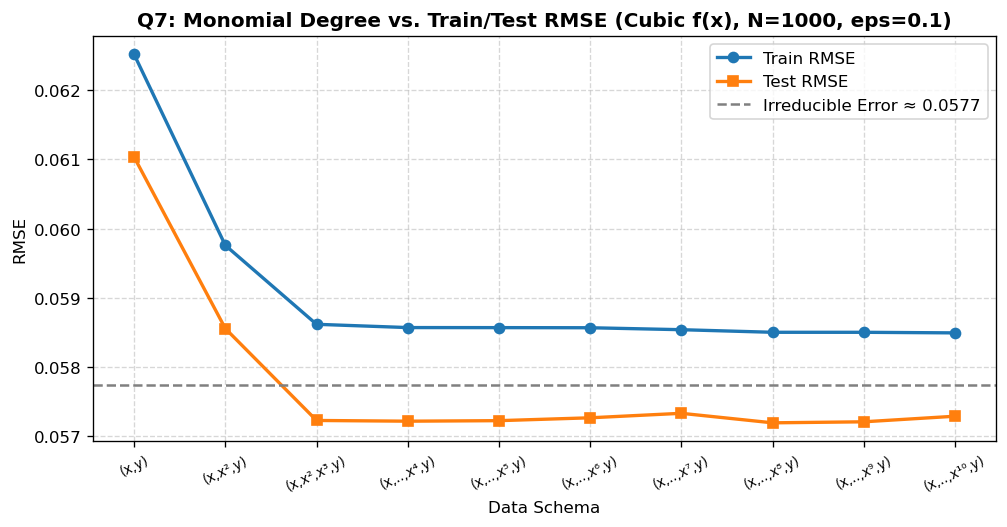

,Degree,Schema,Train RMSE,Test RMSE,Condition Number (XᵀX)
0,1,"(x,y)",0.06252,0.06103,1.87e+01
1,2,"(x,x²,y)",0.05976,0.05855,5.11e+02
2,3,"(x,x²,x³,y)",0.05862,0.05722,1.61e+04
3,4,"(x,..,x⁴,y)",0.05857,0.05721,4.92e+05
4,5,"(x,..,x⁵,y)",0.05857,0.05722,1.54e+07
5,6,"(x,..,x⁶,y)",0.05857,0.05726,5.10e+08
6,7,"(x,..,x⁷,y)",0.05854,0.05733,1.68e+10
7,8,"(x,..,x⁸,y)",0.05850,0.05719,5.60e+11
8,9,"(x,..,x⁹,y)",0.05850,0.05720,1.87e+13
9,10,"(x,..,x¹⁰,y)",0.05849,0.05729,6.07e+14


In [6]:
degrees = list(range(1, 11))

poly_funcs = [lambda x, p=p: x**p for p in range(2, 11)]

X10, y_q7, x_raw_q7 = generate_noisy_dataset(
    func_list=poly_funcs,
    true_func=cubic_func,
    x_range=[0.0, 1.0],
    n_samples=1000,
    noise_level=0.1,
    random_state=SEED
)

X10_tr, y_tr, X10_te, y_te, _, _ = split_dataset(
    X10, y_q7, x_raw_q7, train_ratio=0.8, random_state=SEED
)

q7_tr_rmse = []
q7_te_rmse = []
q7_cond_nums = []

for d in degrees:
    X_tr_sub = X10_tr[:, :d]
    X_te_sub = X10_te[:, :d]

    ones_tr = np.ones((X_tr_sub.shape[0], 1))
    X_tr_aug = np.hstack([ones_tr, X_tr_sub])
    cond_num = np.linalg.cond(X_tr_aug.T @ X_tr_aug)
    q7_cond_nums.append(cond_num)

    beta_d = fit(X_tr_sub, y_tr)

    train_pred = predict(beta_d, X_tr_sub)
    test_pred = predict(beta_d, X_te_sub)

    q7_tr_rmse.append(evaluate_model(train_pred, y_tr))
    q7_te_rmse.append(evaluate_model(test_pred, y_te))

fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.plot(degrees, q7_tr_rmse, 'o-', label='Train RMSE', linewidth=2)
ax.plot(degrees, q7_te_rmse, 's-', label='Test RMSE', linewidth=2)

irreducible_error = 0.1 / np.sqrt(3)
ax.axhline(
    irreducible_error,
    linestyle='--',
    color='gray',
    label=f'Irreducible Error ≈ {irreducible_error:.4f}'
)

schema_labels = [
    "(x,y)",
    "(x,x²,y)",
    "(x,x²,x³,y)",
    "(x,..,x⁴,y)",
    "(x,..,x⁵,y)",
    "(x,..,x⁶,y)",
    "(x,..,x⁷,y)",
    "(x,..,x⁸,y)",
    "(x,..,x⁹,y)",
    "(x,..,x¹⁰,y)"
]

ax.set_xticks(degrees)
ax.set_xticklabels(schema_labels, rotation=25, fontsize=8)

ax.set_xlabel('Data Schema')
ax.set_ylabel('RMSE')
ax.set_title('Q7: Monomial Degree vs. Train/Test RMSE (Cubic f(x), N=1000, eps=0.1)', fontweight='bold')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "Degree": degrees,
        "Schema": schema_labels,
        "Train RMSE": [round(r, 5) for r in q7_tr_rmse],
        "Test RMSE": [round(r, 5) for r in q7_te_rmse],
        "Condition Number (XᵀX)": [f"{c:.2e}" for c in q7_cond_nums]
    })
)


---
## Part 6: Regression Tree Experiments (Q9)
Evaluates Decision Trees across all 24 setup combinations (Linear & Cubic true functions, noise 0.01 vs. 0.1, raw vs. poly schemas, `min_records` 1000, 50, 1).


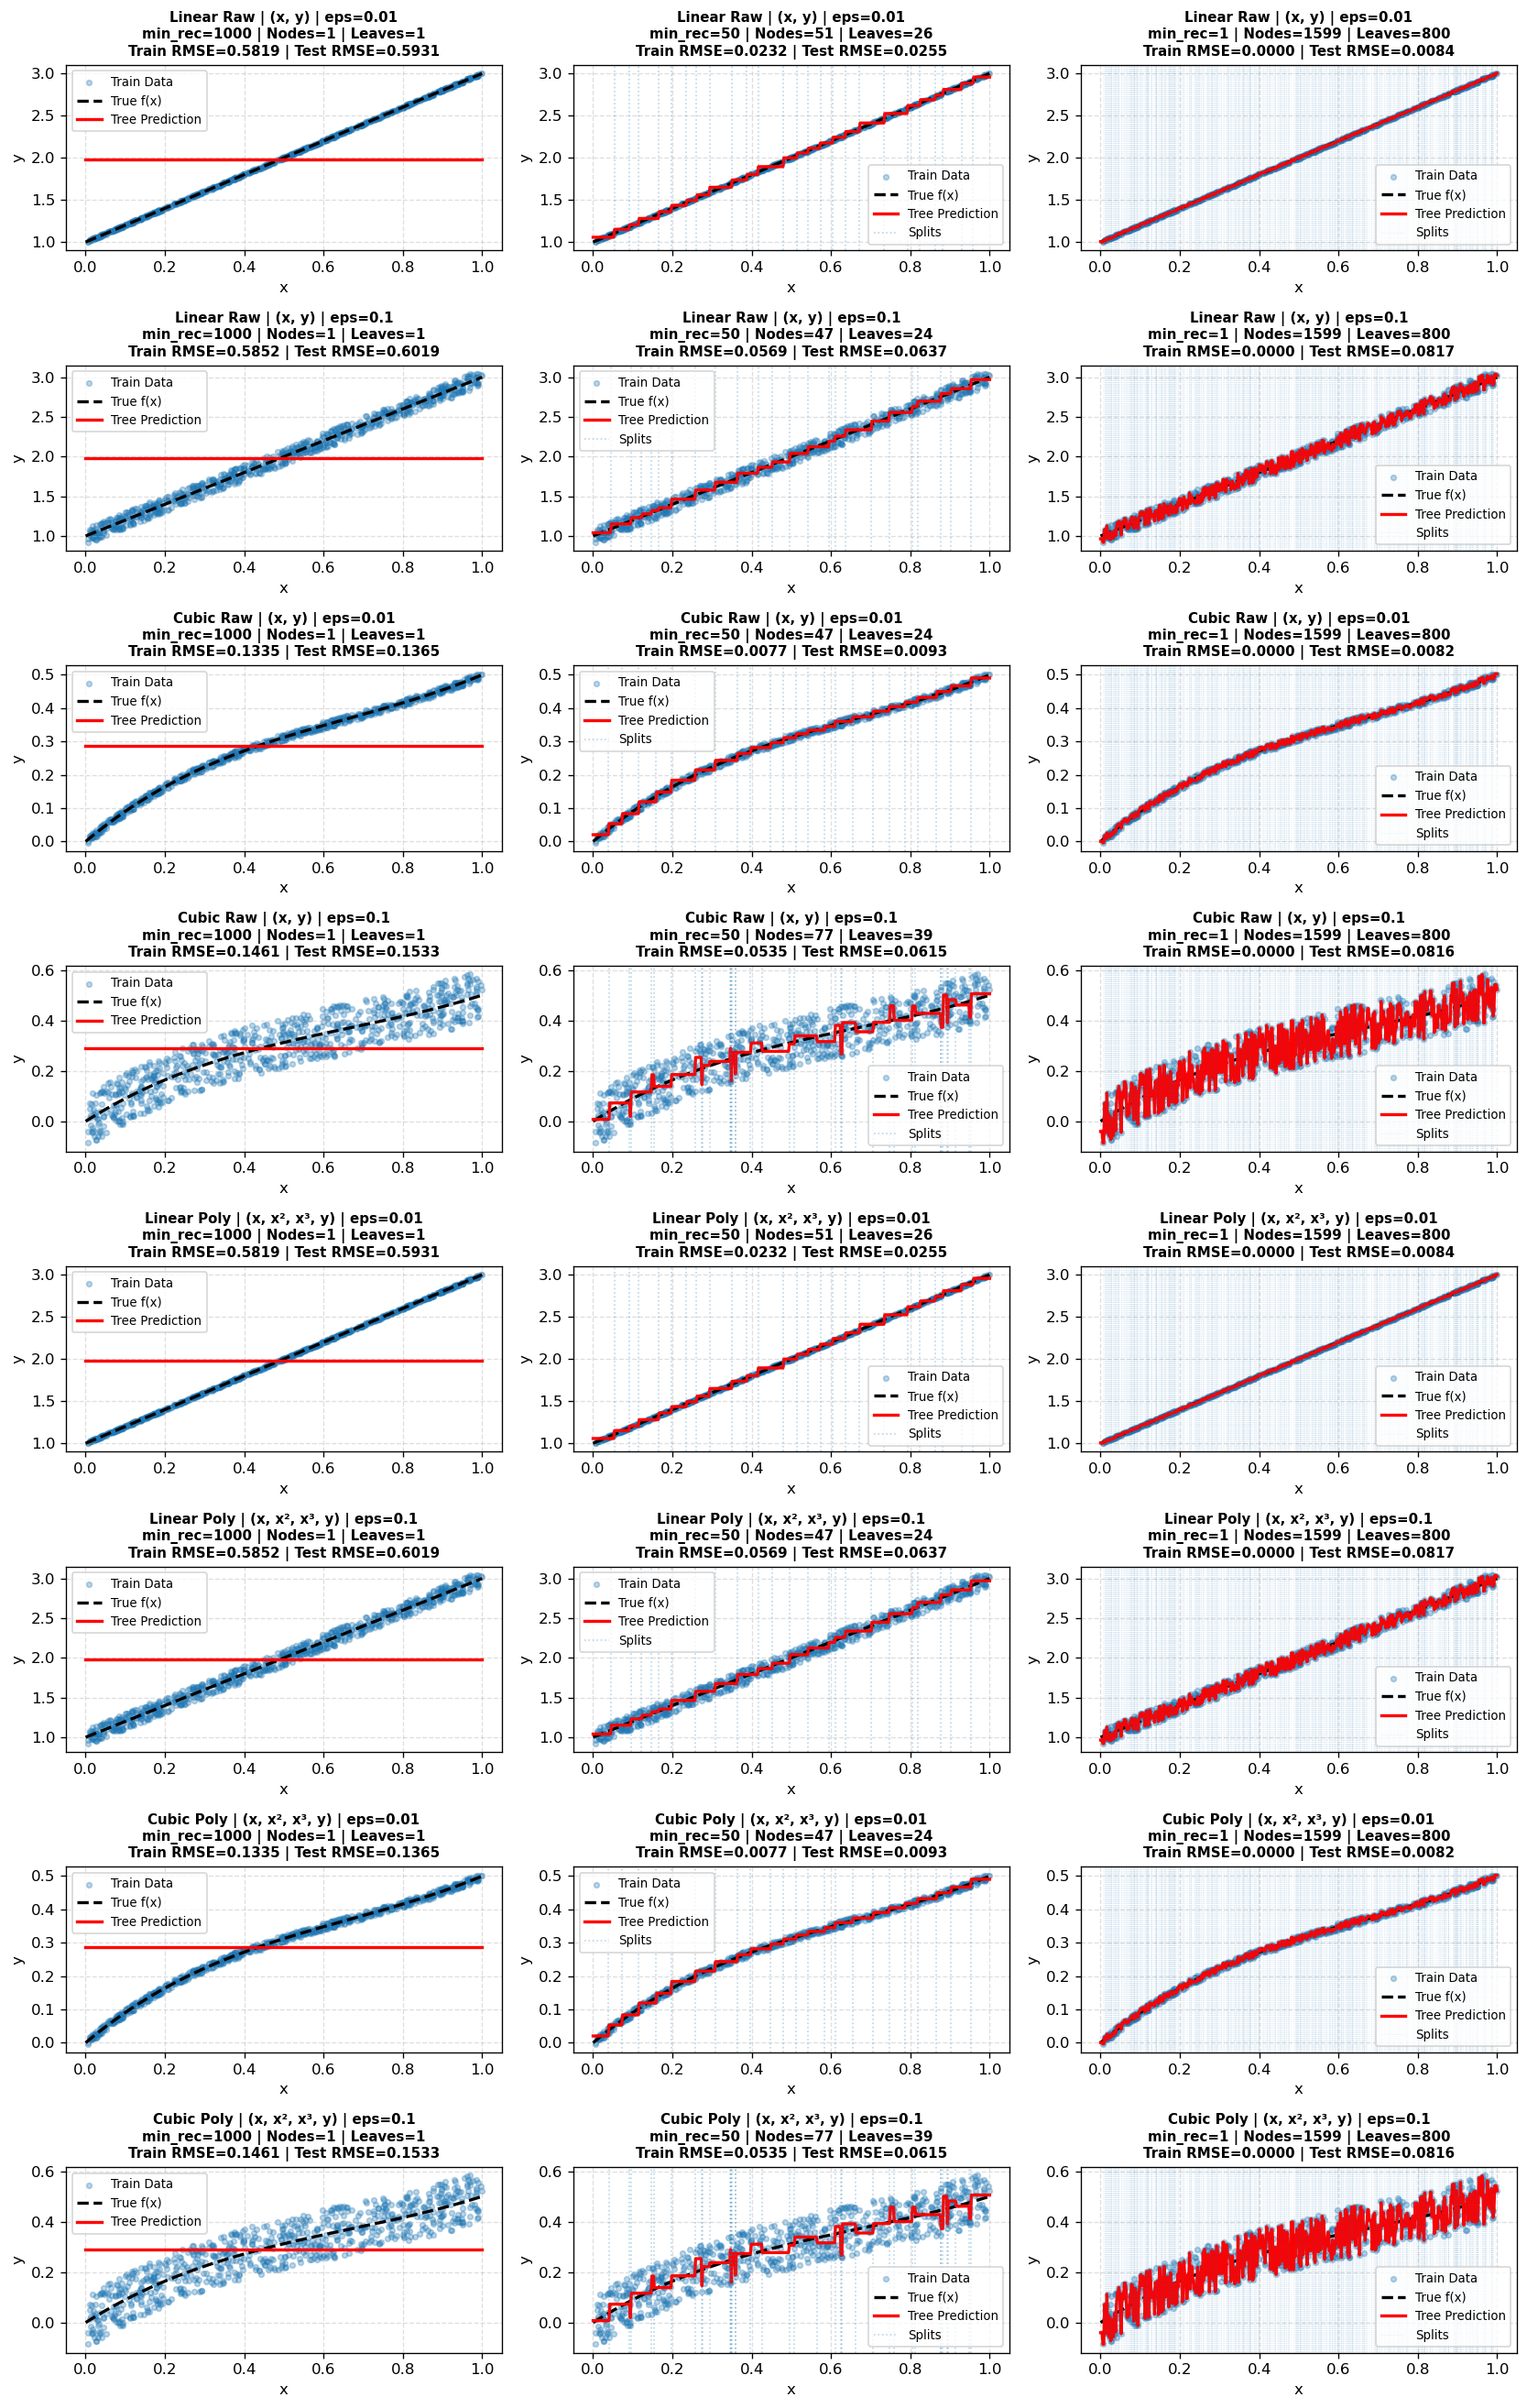

,Setup,True fn,Noise,Schema,min_records,Nodes,Leaves,Leaf size min/med/max,Train RMSE,Test RMSE
0,Linear Raw,Linear,0.01,"(x, y)",1000,1,1,800/800/800,0.58192,0.59314
1,Linear Raw,Linear,0.01,"(x, y)",50,51,26,16/29/47,0.02322,0.02545
2,Linear Raw,Linear,0.01,"(x, y)",1,1599,800,1/1/1,0.00000,0.00844
3,Linear Raw,Linear,0.10,"(x, y)",1000,1,1,800/800/800,0.58523,0.60190
4,Linear Raw,Linear,0.10,"(x, y)",50,47,24,16/34/46,0.05692,0.06374
5,Linear Raw,Linear,0.10,"(x, y)",1,1599,800,1/1/1,0.00000,0.08169
6,Cubic Raw,Cubic,0.01,"(x, y)",1000,1,1,800/800/800,0.13349,0.13646
7,Cubic Raw,Cubic,0.01,"(x, y)",50,47,24,24/32/46,0.00774,0.00933
8,Cubic Raw,Cubic,0.01,"(x, y)",1,1599,800,1/1/1,0.00000,0.00819
9,Cubic Raw,Cubic,0.10,"(x, y)",1000,1,1,800/800/800,0.14613,0.15330



--- Q10: Tree vs Linear Model RMSE Comparison ---


,True fn,Schema,Noise,min_records,Nodes,Leaves,Test RMSE (Tree),Test RMSE (Linear)
0,Linear,"(x, y)",0.01,1000,1,1,0.59314,0.00573
1,Linear,"(x, y)",0.01,50,51,26,0.02545,0.00573
2,Linear,"(x, y)",0.01,1,1599,800,0.00844,0.00573
3,Linear,"(x, y)",0.10,1000,1,1,0.60190,0.05731
4,Linear,"(x, y)",0.10,50,47,24,0.06374,0.05731
5,Linear,"(x, y)",0.10,1,1599,800,0.08169,0.05731
6,Cubic,"(x, y)",0.01,1000,1,1,0.13646,0.02195
7,Cubic,"(x, y)",0.01,50,47,24,0.00933,0.02195
8,Cubic,"(x, y)",0.01,1,1599,800,0.00819,0.02195
9,Cubic,"(x, y)",0.10,1000,1,1,0.15330,0.06103


In [7]:
tree_min_recs = [1000, 50, 1]

tree_base_setups = [
    {"name": "Linear Raw", "true_fn": "Linear", "func": linear_func, "noise": 0.01,
     "funcs": [], "schema": "(x, y)"},

    {"name": "Linear Raw", "true_fn": "Linear", "func": linear_func, "noise": 0.1,
     "funcs": [], "schema": "(x, y)"},

    {"name": "Cubic Raw", "true_fn": "Cubic", "func": cubic_func, "noise": 0.01,
     "funcs": [], "schema": "(x, y)"},

    {"name": "Cubic Raw", "true_fn": "Cubic", "func": cubic_func, "noise": 0.1,
     "funcs": [], "schema": "(x, y)"},

    {"name": "Linear Poly", "true_fn": "Linear", "func": linear_func, "noise": 0.01,
     "funcs": [square_func, cube_func],
     "schema": "(x, x², x³, y)"},

    {"name": "Linear Poly", "true_fn": "Linear", "func": linear_func, "noise": 0.1,
     "funcs": [square_func, cube_func],
     "schema": "(x, x², x³, y)"},

    {"name": "Cubic Poly", "true_fn": "Cubic", "func": cubic_func, "noise": 0.01,
     "funcs": [square_func, cube_func],
     "schema": "(x, x², x³, y)"},

    {"name": "Cubic Poly", "true_fn": "Cubic", "func": cubic_func, "noise": 0.1,
     "funcs": [square_func, cube_func],
     "schema": "(x, x², x³, y)"}
]

tree_results = []

fig, axes = plt.subplots(8, 3, figsize=(14, 22))
axes = axes.flatten()

plot_idx = 0

for setup in tree_base_setups:
    X, y, x_raw = generate_noisy_dataset(
        func_list=setup["funcs"],
        true_func=setup["func"],
        x_range=[0.0, 1.0],
        n_samples=1000,
        noise_level=setup["noise"],
        random_state=SEED
    )

    X_tr, y_tr, X_te, y_te, x_tr_raw, x_te_raw = split_dataset(
        X, y, x_raw, train_ratio=0.8, random_state=SEED
    )

    for min_rec in tree_min_recs:
        ax = axes[plot_idx]

        tree = RegressionTree()
        tree.fit(X_tr, y_tr, min_records=min_rec)

        train_pred = tree.predict(X_tr)
        test_pred = tree.predict(X_te)

        train_rmse = evaluate_model(train_pred, y_tr)
        test_rmse = evaluate_model(test_pred, y_te)

        nodes, n_leaves, leaf_counts = tree.count_nodes_and_leaves()

        min_leaf = np.min(leaf_counts)
        med_leaf = int(np.median(leaf_counts))
        max_leaf = np.max(leaf_counts)
        leaf_size_str = f"{min_leaf}/{med_leaf}/{max_leaf}"

        title_str = setup['name'] + " | " + setup['schema'] + " | eps=" + str(setup['noise']) + "\nmin_rec=" + str(min_rec) + " | Nodes=" + str(nodes) + " | Leaves=" + str(n_leaves) + "\n" + f"Train RMSE={train_rmse:.4f} | Test RMSE={test_rmse:.4f}"

        tree.visualize(
            x_range=(0.0, 1.0),
            true_func=setup["func"],
            X_train=X_tr,
            y_train=y_tr,
            func_list=setup["funcs"],
            title=title_str,
            ax=ax
        )

        tree_results.append({
            "Setup": setup["name"],
            "True fn": setup["true_fn"],
            "Noise": setup["noise"],
            "Schema": setup["schema"],
            "min_records": min_rec,
            "Nodes": nodes,
            "Leaves": n_leaves,
            "Leaf size min/med/max": leaf_size_str,
            "Train RMSE": round(train_rmse, 5),
            "Test RMSE": round(test_rmse, 5)
        })

        plot_idx += 1

plt.tight_layout()
plt.show()

df_tree_results = pd.DataFrame(tree_results)
display(df_tree_results)

df_merged = pd.merge(
    df_tree_results,
    df_lr_results[["True fn", "Noise", "Schema", "Test RMSE"]],
    on=["True fn", "Noise", "Schema"],
    suffixes=(" (Tree)", " (Linear)")
)

print("\n--- Q10: Tree vs Linear Model RMSE Comparison ---")
display(df_merged[["True fn", "Schema", "Noise", "min_records", "Nodes", "Leaves", "Test RMSE (Tree)", "Test RMSE (Linear)"]])


---
## Part 7: Regression Tree Overfitting Study (Q11)
Evaluates `min_records` stopping parameters $[2, 4, 8, 16, 32, 64, 128, 256]$ on $f(x) = \sin(2\pi x)$ with $N=200$ and noise $\epsilon=0.2$.


Best min_records (lowest test RMSE): 32 (Test RMSE = 0.12298)


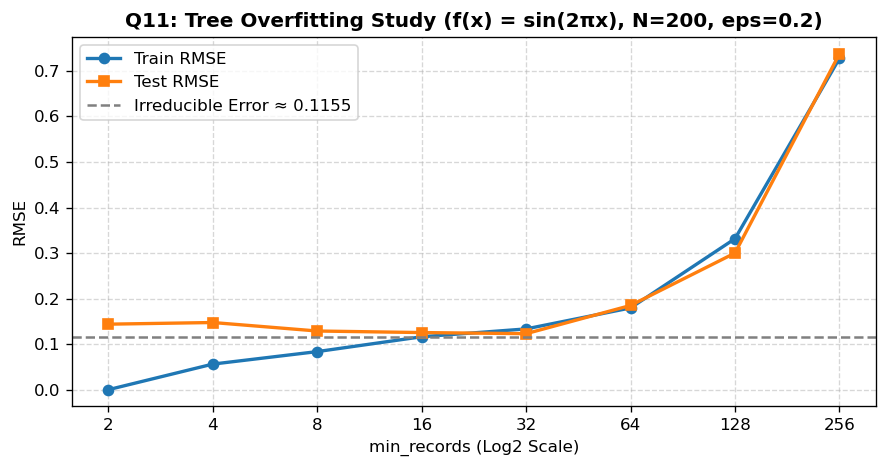

,min_records,Train RMSE,Test RMSE
0,2,0.00000,0.14384
1,4,0.05618,0.14748
2,8,0.08362,0.12882
3,16,0.11619,0.12542
4,32,0.13344,0.12298
5,64,0.17951,0.18496
6,128,0.33161,0.30012
7,256,0.72753,0.73763


In [8]:
sin_func = lambda x: np.sin(2 * np.pi * x)

q11_min_recs = [2, 4, 8, 16, 32, 64, 128, 256]

X, y, x_raw = generate_noisy_dataset(
    func_list=[],
    true_func=sin_func,
    x_range=[0.0, 1.0],
    n_samples=200,
    noise_level=0.2,
    random_state=SEED
)

X_tr, y_tr, X_te, y_te, x_tr_raw, x_te_raw = split_dataset(
    X, y, x_raw, train_ratio=0.8, random_state=SEED
)

q11_tr_rmse = []
q11_te_rmse = []

for min_rec in q11_min_recs:
    tree = RegressionTree()
    tree.fit(X_tr, y_tr, min_records=min_rec)

    train_pred = tree.predict(X_tr)
    test_pred = tree.predict(X_te)

    train_rmse = evaluate_model(train_pred, y_tr)
    test_rmse = evaluate_model(test_pred, y_te)

    q11_tr_rmse.append(train_rmse)
    q11_te_rmse.append(test_rmse)

best_idx = int(np.argmin(q11_te_rmse))
best_min_rec = q11_min_recs[best_idx]
print(f"Best min_records (lowest test RMSE): {best_min_rec} (Test RMSE = {q11_te_rmse[best_idx]:.5f})")

fig, ax = plt.subplots(figsize=(7.5, 4))

ax.plot(q11_min_recs, q11_tr_rmse, 'o-', label='Train RMSE', linewidth=2)
ax.plot(q11_min_recs, q11_te_rmse, 's-', label='Test RMSE', linewidth=2)

irreducible_error = 0.2 / np.sqrt(3)
ax.axhline(
    irreducible_error,
    linestyle='--',
    color='gray',
    label=f'Irreducible Error ≈ {irreducible_error:.4f}'
)

ax.set_xscale('log', base=2)
ax.set_xticks(q11_min_recs)
ax.set_xticklabels([str(min_rec) for min_rec in q11_min_recs])

ax.set_xlabel('min_records (Log2 Scale)')
ax.set_ylabel('RMSE')
ax.set_title('Q11: Tree Overfitting Study (f(x) = sin(2πx), N=200, eps=0.2)', fontweight='bold')
ax.legend(loc='best')
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "min_records": q11_min_recs,
    "Train RMSE": [round(r, 5) for r in q11_tr_rmse],
    "Test RMSE": [round(r, 5) for r in q11_te_rmse]
}))
